# Module 8 — Data Preparation & Statistical Analysis

This notebook extends the Module 7 S3/SageMaker pipeline into a full data-cleaning
and exploratory-analysis workflow using Pandas, NumPy, SciPy, and Matplotlib.

**Workflow:**
1. Load Grad Café JSON from S3
2. Inspect raw data and report missingness
3. Clean and standardize the dataset
4. Engineer derived columns
5. Summary statistics and outlier analysis
6. Statistical analysis with SciPy
7. Matplotlib visualizations
8. Export cleaned dataset back to S3

## 1. Setup and Load Data from S3

Import the required libraries and load AWS credentials from environment variables, then reuse the Module 7 boto3 workflow to pull the raw Grad Cafe JSON dataset from S3 into this notebook.

In [1]:
import os
import re
import json
import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import scipy.stats as stats
from scipy.stats import zscore
from datetime import datetime

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully.
Pandas version: 2.3.3
NumPy version: 2.2.6


In [ ]:
# AWS auth: rely on the IAM role attached to this SageMaker notebook instance.
# boto3 picks this up automatically via its default credential chain --
# no keys are ever read, set, or stored in this notebook.
required = ['AWS_DEFAULT_REGION']
os.environ.setdefault('AWS_DEFAULT_REGION', 'us-east-2')

sts = boto3.client('sts', region_name=os.environ['AWS_DEFAULT_REGION'])
identity = sts.get_caller_identity()
print(f"Authenticated as: {identity['Arn']}")

In [3]:
# Download data from S3
BUCKET = "grad-cafe-ss"
S3_KEY = "llm_extend_applicant_data.json"
LOCAL_FILE = "llm_extend_applicant_data.json"

s3 = boto3.client("s3", region_name=os.environ.get("AWS_DEFAULT_REGION", "us-east-2"))
s3.download_file(BUCKET, S3_KEY, LOCAL_FILE)
print(f"Downloaded s3://{BUCKET}/{S3_KEY} -> {LOCAL_FILE}")

Downloaded s3://grad-cafe-ss/llm_extend_applicant_data.json -> llm_extend_applicant_data.json


In [4]:
# Load JSON into Pandas DataFrame
with open(LOCAL_FILE, encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

# Preserve raw copy before any cleaning
raw_df = df.copy()

print(f"Loaded {len(df)} records with {len(df.columns)} columns.")
print(f"Columns: {list(df.columns)}")

Loaded 30000 records with 18 columns.
Columns: ['program', 'university_raw', 'program_raw', 'comments', 'date_added', 'url', 'status', 'acceptance_date', 'rejection_date', 'term', 'US/International', 'Degree', 'GPA', 'GRE', 'GRE V', 'GRE AW', 'llm-generated-program', 'llm-generated-university']


### 1.1 Initial Data Inspection

Preview the raw dataset and confirm its shape, column names, and dtypes before any cleaning is applied.

In [5]:
# Display first 5 rows
print("First 5 rows of raw dataset:")
display(df.head())

First 5 rows of raw dataset:


,program,university_raw,program_raw,comments,date_added,url,status,acceptance_date,rejection_date,term,US/International,Degree,GPA,GRE,GRE V,GRE AW,llm-generated-program,llm-generated-university
0,"Physics, University of Birmingham",University of Birmingham,Physics,"HEP-ex BSc was top British uni, 55% (2:2) MSc ...","Jun 06, 2026",https://www.thegradcafe.com/result/1020320,Rejected on Jun 02,None,Jun 02,Fall 2026,American,PhD,None,NaN,NaN,NaN,Physics,University of Birmingham
1,"Architecture, University of Guilan",University of Guilan,Architecture,,"Jun 06, 2026",https://www.thegradcafe.com/result/1020319,Accepted on Jun 06,Jun 06,None,Spring 2026,International,Masters,None,NaN,NaN,NaN,Architecture,University of Milan
2,"Instructional designe, All school",All school,Instructional designe,,"Jun 06, 2026",https://www.thegradcafe.com/result/1020318,Accepted on Jun 06,Jun 06,None,Fall 2026,International,Masters,None,NaN,NaN,NaN,Instructional designe,All school
3,"Mathematics, University of Bonn",University of Bonn,Mathematics,,"Jun 06, 2026",https://www.thegradcafe.com/result/1020317,Rejected on Jun 06,None,Jun 06,Fall 2026,International,Masters,3.36,NaN,NaN,NaN,Mathematics,University of Bonn
4,"Public Policy, University of Massachusetts Boston",University of Massachusetts Boston,Public Policy,didn't notice me. i just check the portal by m...,"Jun 05, 2026",https://www.thegradcafe.com/result/1020316,Rejected on Jun 01,None,Jun 01,Fall 2026,International,PhD,3.03,NaN,150.0,2.5,Public Policy,University of Massachusetts Boston


In [6]:
# Save screenshot reminder
print("ACTION REQUIRED: Take a screenshot of the table above and save as initial_dataframe.png")

ACTION REQUIRED: Take a screenshot of the table above and save as initial_dataframe.png


In [7]:
# Report shape, column names, and dtypes
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

Number of rows: 30000
Number of columns: 18

Column names: ['program', 'university_raw', 'program_raw', 'comments', 'date_added', 'url', 'status', 'acceptance_date', 'rejection_date', 'term', 'US/International', 'Degree', 'GPA', 'GRE', 'GRE V', 'GRE AW', 'llm-generated-program', 'llm-generated-university']

Data types:
program                      object
university_raw               object
program_raw                  object
comments                     object
date_added                   object
url                          object
status                       object
acceptance_date              object
rejection_date               object
term                         object
US/International             object
Degree                       object
GPA                          object
GRE                         float64
GRE V                       float64
GRE AW                      float64
llm-generated-program        object
llm-generated-university     object
dtype: object


### 1.2 Missingness Summary

Quantify how much data is missing in each column to guide which cleaning and validation steps are needed later.

In [8]:
# Compute missingness summary
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missingness_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_pct
}).sort_values('missing_percentage', ascending=False)

print("Missingness Summary:")
display(missingness_df)

# Save to CSV
missingness_df.to_csv("missingness_summary.csv")
print("\nSaved: missingness_summary.csv")
print("ACTION REQUIRED: Take a screenshot of the table above and save as missingness_summary.png")

Missingness Summary:


,missing_count,missing_percentage
GRE AW,28193,93.98
GRE V,27993,93.31
GRE,27595,91.98
rejection_date,15937,53.12
acceptance_date,14063,46.88
GPA,11926,39.75
US/International,450,1.50
Degree,169,0.56
program_raw,8,0.03
program,0,0.00



Saved: missingness_summary.csv
ACTION REQUIRED: Take a screenshot of the table above and save as missingness_summary.png


## 2. Clean and Standardize the Dataset

Transform the raw, inconsistent fields into standardized, analysis-ready columns.

### 2.1 Remove Rows Where Program is None

Rows with no program value carry no usable information for this analysis, so they are removed first, before any other cleaning.

In [9]:
# Track rows removed at each step
cleaning_log = {}
initial_rows = len(df)

# Remove rows where program is None
df = df[df['program'].notna()].copy()
cleaning_log['removed_null_program'] = initial_rows - len(df)
print(f"Removed {cleaning_log['removed_null_program']} rows where program is None.")
print(f"Remaining rows: {len(df)}")

Removed 0 rows where program is None.
Remaining rows: 30000


### 2.2 Split Program into Program and University Columns

The source data already provides program_raw and university_raw as pre-split fields, so those are used directly (with a fallback to the llm-generated fields for the handful of rows missing program_raw) rather than re-parsing the combined program string.

In [10]:
# The source data already provides program_raw (program name only) and
# university_raw (university name only) as pre-split fields, so we use those
# directly rather than re-parsing the combined 'program' field with regex.
df['Program'] = df['program_raw']
df['University'] = df['university_raw']

# A small number of rows (8) are missing program_raw. For those, fall back
# to the llm-generated-program / llm-generated-university columns.
missing_program_mask = df['Program'].isna()
df.loc[missing_program_mask, 'Program'] = df.loc[missing_program_mask, 'llm-generated-program']
df.loc[missing_program_mask, 'University'] = df.loc[missing_program_mask, 'University'].fillna(
    df.loc[missing_program_mask, 'llm-generated-university']
)

print("Program/University sourced from program_raw/university_raw columns.")
print(f"Rows requiring llm-generated fallback: {missing_program_mask.sum()}")
print(f"Remaining missing Program after fallback: {df['Program'].isna().sum()}")
print(df[['program', 'Program', 'University']].head(3))

Program/University sourced from program_raw/university_raw columns.
Rows requiring llm-generated fallback: 8
Remaining missing Program after fallback: 0
                              program                Program  \
0   Physics, University of Birmingham                Physics   
1  Architecture, University of Guilan           Architecture   
2   Instructional designe, All school  Instructional designe   

                 University  
0  University of Birmingham  
1      University of Guilan  
2                All school  


### 2.3 Clean Text Columns

Strip leading/trailing whitespace and collapse repeated internal whitespace across key text columns so downstream grouping and comparisons are consistent.

In [11]:
# Strip whitespace and collapse repeated internal whitespace
text_cols = ['Program', 'University', 'status', 'term', 'US/International', 'Degree']

for col in text_cols:
    if col in df.columns:
        df[col] = (df[col]
                   .astype(str)
                   .str.strip()
                   .str.replace(r'\s+', ' ', regex=True)
                   .replace('nan', np.nan))

print("Text columns cleaned.")

Text columns cleaned.


### 2.4 Program Count Analysis

Identify program labels that occur fewer than 3 times, which may indicate one-off entries, typos, or inconsistent naming.

In [12]:
# Count occurrences of each unique Program value
program_counts = df['Program'].value_counts()
print(f"Total unique programs: {len(program_counts)}")
print(f"\nTop 10 programs:")
print(program_counts.head(10))

# Programs with fewer than 3 occurrences
low_count_programs = program_counts[program_counts < 3]
print(f"\nPrograms with fewer than 3 occurrences: {len(low_count_programs)}")
display(low_count_programs.reset_index().rename(columns={'Program': 'program', 'count': 'count'}))
print("ACTION REQUIRED: Take a screenshot of the output above and save as low_program_count.png")

Total unique programs: 3060

Top 10 programs:
Program
Computer Science       1589
Physics                1429
Economics              1392
Philosophy             1169
English                1130
Political Science       958
Sociology               955
Mathematics             896
History                 869
Clinical Psychology     819
Name: count, dtype: int64

Programs with fewer than 3 occurrences: 2346


,program,count
0,XDBio,2
1,Biomolecular Engineering and Bioinformatics (B...,2
2,Health Sciences,2
3,Health Science,2
4,Public Policy and Management: Data Analytics (...,2
...,...,...
2341,Cancer Science,1
2342,Medical Dosimetry,1
2343,Chicken Farming,1
2344,Astrophysisc,1


ACTION REQUIRED: Take a screenshot of the output above and save as low_program_count.png


### 2.5 Convert date_added to Datetime

Convert date_added from a text field to a true datetime dtype so later date arithmetic (e.g. days_to_decision) works correctly.

In [13]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print(f"date_added converted to datetime.")
print(f"Valid dates: {df['date_added'].notna().sum()}")
print(f"Invalid/missing dates: {df['date_added'].isna().sum()}")
print(df['date_added'].head())

date_added converted to datetime.
Valid dates: 30000
Invalid/missing dates: 0
0   2026-06-06
1   2026-06-06
2   2026-06-06
3   2026-06-06
4   2026-06-05
Name: date_added, dtype: datetime64[ns]


### 2.6 Split Status into Outcome and Decision Date

Extract a standardized outcome category from the status text via keyword matching,
then parse decision_date directly from the status text itself (format
'<Outcome> on <Mon DD>'), using term to infer the missing year. Parsing from status
directly -- rather than only the acceptance_date/rejection_date columns -- means
Waitlisted and Interviewed rows with a visible date are captured too, since those
two columns only exist for Accepted/Rejected outcomes.

In [14]:
OUTCOME_KEYWORDS = {
    'Accepted': 'Accepted',
    'Rejected': 'Rejected',
    'Waitlisted': 'Waitlisted',
    'Wait Listed': 'Waitlisted',
    'Interviewed': 'Interviewed',
    'Interview': 'Interviewed',
}

def parse_outcome(status_str):
    """Extract standardized outcome from status string."""
    if not isinstance(status_str, str) or status_str.strip() == '':
        return np.nan
    for key, val in OUTCOME_KEYWORDS.items():
        if key.lower() in status_str.lower():
            return val
    return np.nan

df['outcome'] = df['status'].apply(parse_outcome)

print("Outcome value counts:")
print(df['outcome'].value_counts())

Outcome value counts:
outcome
Rejected       14063
Accepted       11144
Waitlisted      2722
Interviewed     2071
Name: count, dtype: int64


In [ ]:
# Use term to infer decision year (e.g. 'Fall 2024' -> 2024)
def extract_year_from_term(term_str):
    """Extract year from term like 'Fall 2024'."""
    if not isinstance(term_str, str):
        return None
    match = re.search(r'(\d{4})', term_str)
    return int(match.group(1)) if match else None

df['term_year'] = df['term'].apply(extract_year_from_term)

# Parse decision_date directly from the status text (format '<Outcome> on <Mon DD>'),
# using term_year to fill in the missing year, since source dates have no year.
# Parsing from status itself (rather than acceptance_date/rejection_date) means
# Waitlisted and Interviewed rows with a visible date are captured too, not just
# Accepted/Rejected.
def parse_decision_date(row):
    """Extract decision date from the status string for any outcome."""
    status_str = row['status']
    if not isinstance(status_str, str):
        return pd.NaT

    match = re.search(r'on\s+([A-Za-z]{3}\s+\d{1,2})', status_str)
    if not match:
        return pd.NaT

    raw = match.group(1)
    year = row['term_year']
    date_str = f"{raw} {year}" if year else raw
    return pd.to_datetime(date_str, format='%b %d %Y', errors='coerce')

df['decision_date'] = df.apply(parse_decision_date, axis=1)

print(f"Decision dates parsed: {df['decision_date'].notna().sum()}")
print(df[['status', 'outcome', 'decision_date']].head(10))
print("ACTION REQUIRED: Take a screenshot of the output above and save as date_based.png")

### 2.7 Clean Degree Column

Normalize known spelling variants (the source data spells it 'Masters' with no apostrophe) to the required "Master's" form, then drop any row whose Degree value falls outside the three accepted categories.

In [16]:
# Normalize known Degree spelling variants before validating.
# Source data spells it 'Masters' (no apostrophe) instead of "Master's".
DEGREE_NORMALIZATION = {
    'Masters': "Master's",
}
df['Degree'] = df['Degree'].replace(DEGREE_NORMALIZATION)

# Valid degree values
VALID_DEGREES = ["Master's", "PhD", "PsyD"]

before = len(df)
df = df[df['Degree'].isin(VALID_DEGREES)].copy()
cleaning_log['removed_invalid_degree'] = before - len(df)
print("Normalized Degree spelling variants (e.g. 'Masters' -> \"Master's\").")
print(f"Removed {cleaning_log['removed_invalid_degree']} rows with invalid Degree values.")
print(f"Remaining rows: {len(df)}")
print(df['Degree'].value_counts())

Normalized Degree spelling variants (e.g. 'Masters' -> "Master's").
Removed 169 rows with invalid Degree values.
Remaining rows: 29831
Degree
PhD         21688
Master's     8143
Name: count, dtype: int64


### 2.8 Clean US/International Column

Set any value outside the three valid categories to missing rather than dropping the row, since the rest of the row may still be usable.

In [ ]:
# Valid US/International values
VALID_INTL = ['International', 'American', 'Other']

before = len(df)
invalid_mask = ~df['US/International'].isin(VALID_INTL)
cleaning_log['invalid_intl_mapped_to_other'] = int(invalid_mask.sum())
df.loc[invalid_mask, 'US/International'] = 'Other'

print(f"Mapped {cleaning_log['invalid_intl_mapped_to_other']} invalid US/International values to 'Other'.")
print(df['US/International'].value_counts())

### 2.9 Convert Numeric Columns to Float

Convert GPA, GRE, GRE V, and GRE AW to numeric dtype, and null out GRE/GRE V values outside the real score range to remove an out-of-range sentinel placeholder (999) used in the source data for 'not reported.'

In [18]:
# Convert GPA, GRE, GRE V, GRE AW to float
numeric_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# The source data uses out-of-range sentinel values (e.g. 999) to represent
# 'not reported' for GRE-related fields instead of leaving them null.
# Treat scores outside the real GRE scale as missing rather than valid data.
GRE_VALID_RANGE = (260, 340)    # Combined Verbal + Quantitative scale
GRE_V_VALID_RANGE = (130, 170)  # Verbal section scale

gre_sentinel_mask = df['GRE'].notna() & ~df['GRE'].between(*GRE_VALID_RANGE)
gre_v_sentinel_mask = df['GRE V'].notna() & ~df['GRE V'].between(*GRE_V_VALID_RANGE)

cleaning_log['gre_sentinel_nulled'] = int(gre_sentinel_mask.sum())
cleaning_log['gre_v_sentinel_nulled'] = int(gre_v_sentinel_mask.sum())

df.loc[gre_sentinel_mask, 'GRE'] = np.nan
df.loc[gre_v_sentinel_mask, 'GRE V'] = np.nan

print("Numeric columns converted to float:")
print(df[numeric_cols].dtypes)
print(f"\nGRE out-of-range sentinel values set to NaN: {cleaning_log['gre_sentinel_nulled']}")
print(f"GRE V out-of-range sentinel values set to NaN: {cleaning_log['gre_v_sentinel_nulled']}")
print(f"\nSample values:")
display(df[numeric_cols].head())
print("ACTION REQUIRED: Take a screenshot of the output above and save as float_columns.png")

Numeric columns converted to float:
GPA       float64
GRE       float64
GRE V     float64
GRE AW    float64
dtype: object

GRE out-of-range sentinel values set to NaN: 989
GRE V out-of-range sentinel values set to NaN: 3

Sample values:


,GPA,GRE,GRE V,GRE AW
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,3.36,NaN,NaN,NaN
4,3.03,NaN,150.0,2.5


ACTION REQUIRED: Take a screenshot of the output above and save as float_columns.png


### 2.10 Data Validation Report

Summarize how many rows or values were affected by each cleaning rule and compare the raw row count against the cleaned row count.

In [19]:
# Final cleaning report
final_rows = len(df)
total_removed = initial_rows - final_rows

print("=" * 50)
print("DATA VALIDATION REPORT")
print("=" * 50)
print(f"Initial row count:          {initial_rows}")
print(f"Final row count:            {final_rows}")
print(f"Total rows removed:         {total_removed}")
print(f"\nRows removed by rule:")
for rule, count in cleaning_log.items():
    print(f"  {rule}: {count}")
print(f"\nFinal dataset shape: {df.shape}")

DATA VALIDATION REPORT
Initial row count:          30000
Final row count:            29831
Total rows removed:         169

Rows removed by rule:
  removed_null_program: 0
  removed_invalid_degree: 169
  invalid_intl_set_null: 445
  gre_sentinel_nulled: 989
  gre_v_sentinel_nulled: 3

Final dataset shape: (29831, 23)


## 3. Feature Engineering — Derived Columns

Engineer new analytical columns using vectorized Pandas/NumPy operations, documented individually below.

## has_valid_gpa, has_valid_gre, has_valid_gre_v

Boolean validity flags computed with vectorized NumPy comparisons:
- `has_valid_gpa`: 1 if `GPA` is present and falls within the real 0.0-4.0 scale, else 0.
- `has_valid_gre`: 1 if `GRE` is present and greater than 0 (out-of-range sentinel values were already nulled in Section 2.9), else 0.
- `has_valid_gre_v`: 1 if `GRE V` is present and greater than 0 (same sentinel cleanup applied), else 0.

In [20]:
# has_valid_gpa: 1 if GPA is present and between 0 and 4.0 inclusive
df['has_valid_gpa'] = np.where(
    df['GPA'].notna() & (df['GPA'] >= 0) & (df['GPA'] <= 4.0), 1, 0
)

# has_valid_gre: 1 if GRE is present and greater than 0
df['has_valid_gre'] = np.where(
    df['GRE'].notna() & (df['GRE'] > 0), 1, 0
)

# has_valid_gre_v: 1 if GRE V is present and greater than 0
df['has_valid_gre_v'] = np.where(
    df['GRE V'].notna() & (df['GRE V'] > 0), 1, 0
)

print("Derived validation columns created:")
print(f"  has_valid_gpa:   {df['has_valid_gpa'].sum()} valid")
print(f"  has_valid_gre:   {df['has_valid_gre'].sum()} valid")
print(f"  has_valid_gre_v: {df['has_valid_gre_v'].sum()} valid")

Derived validation columns created:
  has_valid_gpa:   17944 valid
  has_valid_gre:   1415 valid
  has_valid_gre_v: 2003 valid


## days_to_decision

Computed as the vectorized difference in days between `decision_date` and `date_added` (`(decision_date - date_added).dt.days`). Left as missing (`NaN`) for any row where `decision_date` could not be determined, since there is nothing to subtract.

In [21]:
# days_to_decision: difference in days between decision_date and date_added
df['days_to_decision'] = (df['decision_date'] - df['date_added']).dt.days
df.loc[df['decision_date'].isna(), 'days_to_decision'] = np.nan

print(f"days_to_decision computed for {df['days_to_decision'].notna().sum()} rows.")
print(df['days_to_decision'].describe())

days_to_decision computed for 25079 rows.
count    25079.000000
mean        -1.824116
std         45.026018
min       -403.000000
25%         -2.000000
50%          0.000000
75%          0.000000
max        343.000000
Name: days_to_decision, dtype: float64


## decision_speed

A categorical bucket built with `np.select` over `abs(days_to_decision)`:
- `0-30 days`
- `31-60 days`
- `61+ days`
- `Unknown` (used when `days_to_decision` is missing)

Bucketed on absolute value rather than raw signed value: `date_added` is the
applicant's post date and `decision_date` is when the school actually decided, so
posting normally happens on or shortly *after* the decision -- meaning
`days_to_decision` is typically negative or zero. That is the expected pattern for
this dataset, not a data-quality problem, so negative and positive lags of the
same magnitude are treated as the same 'speed'.

In [ ]:
# decision_speed: categorical using np.select, bucketed on absolute posting lag.
# date_added is when the applicant POSTED to GradCafe; decision_date is when the
# school actually decided. Posting normally happens on or shortly after the
# decision (decision_date <= date_added), so days_to_decision is typically
# negative or zero -- that is the expected pattern here, not bad data. Bucketing
# is done on abs(days_to_decision) so posting lag in either direction is treated
# as the same 'speed', rather than the earlier version which wrongly treated all
# negative values as a data-quality problem and dumped them into Unknown.
abs_days = df['days_to_decision'].abs()

conditions = [
    df['days_to_decision'].isna(),
    abs_days <= 30,
    (abs_days > 30) & (abs_days <= 60),
    abs_days > 60,
]
choices = ['Unknown', '0-30 days', '31-60 days', '61+ days']

df['decision_speed'] = np.select(conditions, choices, default='Unknown')
print("decision_speed distribution:")
print(df['decision_speed'].value_counts())

## application_season

Derived from the month of `date_added` using `np.select`, split into even
four-month thirds of the year:
- **Early Cycle**: September-December
- **Mid Cycle**: January-April
- **Late Cycle**: May-August

Every month maps to exactly one of the three required categories; there is no
Unknown bucket, per the assignment spec. The assignment does not specify exact
month boundaries, so an even split was used rather than assuming a particular
admissions-calendar shape.

In [ ]:
# application_season: derived from month of date_added
# Even four-month thirds of the year, with no data-derived semantics assumed:
# Early Cycle: Sep-Dec, Mid Cycle: Jan-Apr, Late Cycle: May-Aug.
# Every month maps to exactly one of the three required categories.
month = df['date_added'].dt.month

conditions = [
    month.isin([9, 10, 11, 12]),
    month.isin([1, 2, 3, 4]),
    month.isin([5, 6, 7, 8]),
]
choices = ['Early Cycle', 'Mid Cycle', 'Late Cycle']

df['application_season'] = np.select(conditions, choices, default='Mid Cycle')
print("application_season distribution:")
print(df['application_season'].value_counts())

## 4. Summary Statistics and Outlier Analysis

Compute descriptive statistics for the numeric columns and flag potential outliers using z-scores.

### 4.1 Descriptive Statistics

Compute count, mean, median, standard deviation, min, max, and the 25th/50th/75th percentiles for each numeric column.

In [24]:
# Compute descriptive statistics for numeric columns
numeric_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']

stats_dict = {}
for col in numeric_cols:
    valid = df[col].dropna()
    valid = valid[valid > 0] if col != 'GPA' else valid
    if len(valid) > 0:
        stats_dict[col] = {
            'count': len(valid),
            'mean': np.mean(valid),
            'median': np.median(valid),
            'std': np.std(valid),
            'min': np.min(valid),
            'max': np.max(valid),
            '25th_percentile': np.percentile(valid, 25),
            '50th_percentile': np.percentile(valid, 50),
            '75th_percentile': np.percentile(valid, 75),
        }

summary_stats_df = pd.DataFrame(stats_dict).T.round(4)
print("Descriptive Statistics:")
display(summary_stats_df)

summary_stats_df.to_csv("summary_statistics.csv")
print("\nSaved: summary_statistics.csv")

Descriptive Statistics:


,count,mean,median,std,min,max,25th_percentile,50th_percentile,75th_percentile
GPA,17944.0,3.7741,3.85,0.2466,0.0,4.0,3.68,3.85,3.95
GRE,1415.0,325.4700,327.00,9.3820,291.0,340.0,321.00,327.00,332.00
GRE V,2003.0,160.7514,161.00,6.2839,134.0,170.0,157.00,161.00,166.00
GRE AW,1806.0,4.3547,4.50,0.7870,2.0,6.0,4.00,4.50,5.00



Saved: summary_statistics.csv


### 4.2 Outlier Analysis using SciPy Z-Score

Flag GPA and GRE values whose absolute z-score exceeds 3 as potential outliers, and record the decision to keep or remove them.

In [25]:
# GPA outliers — use valid GPA values
gpa_valid = df['GPA'].dropna()
gpa_valid = gpa_valid[(gpa_valid >= 0) & (gpa_valid <= 4.0)]
gpa_z = zscore(gpa_valid)
gpa_outlier_mask = np.abs(gpa_z) > 3

df['gpa_outlier'] = False
df.loc[gpa_valid.index, 'gpa_outlier'] = gpa_outlier_mask

# GRE outliers — use valid GRE values
gre_valid = df['GRE'].dropna()
gre_valid = gre_valid[gre_valid > 0]
gre_z = zscore(gre_valid)
gre_outlier_mask = np.abs(gre_z) > 3

df['gre_outlier'] = False
df.loc[gre_valid.index, 'gre_outlier'] = gre_outlier_mask

print("Outlier Analysis (|z-score| > 3):")
print(f"  GPA outliers:  {df['gpa_outlier'].sum()}")
print(f"  GRE outliers:  {df['gre_outlier'].sum()}")
print("\nDecision: Outliers are KEPT in the dataset.")
print("Rationale: GPA and GRE outliers may represent legitimate extreme cases.")
print("           Removing them could bias analysis of high/low performers.")
print("\nOutlier summary:")
outlier_summary = pd.DataFrame({
    'column': ['GPA', 'GRE'],
    'total_valid': [len(gpa_valid), len(gre_valid)],
    'outliers_found': [df['gpa_outlier'].sum(), df['gre_outlier'].sum()],
    'outlier_pct': [
        round(df['gpa_outlier'].sum() / len(gpa_valid) * 100, 2),
        round(df['gre_outlier'].sum() / len(gre_valid) * 100, 2)
    ],
    'action': ['Kept', 'Kept']
})
display(outlier_summary)
print("ACTION REQUIRED: Take a screenshot of the output above and save as outlier_summary.png")

Outlier Analysis (|z-score| > 3):
  GPA outliers:  255
  GRE outliers:  1

Decision: Outliers are KEPT in the dataset.
Rationale: GPA and GRE outliers may represent legitimate extreme cases.
           Removing them could bias analysis of high/low performers.

Outlier summary:


,column,total_valid,outliers_found,outlier_pct,action
0,GPA,17944,255,1.42,Kept
1,GRE,1415,1,0.07,Kept


ACTION REQUIRED: Take a screenshot of the output above and save as outlier_summary.png


## 5. Statistical Analysis with SciPy

Run correlation, group-comparison, and categorical-association tests to describe relationships in the cleaned data.

### 5A. Correlation Analysis

Measure the strength and direction of the relationship between GRE-related measures and between GPA and GRE.

In [26]:
# Pearson correlation: GRE vs GRE V (non-zero values only)
gre_grev = df[(df['GRE'] > 0) & (df['GRE V'] > 0)][['GRE', 'GRE V']].dropna()
r_gre_grev, p_gre_grev = stats.pearsonr(gre_grev['GRE'], gre_grev['GRE V'])

print("=== Pearson Correlation: GRE vs GRE V ===")
print(f"Correlation coefficient: {r_gre_grev:.4f}")
print(f"P-value:                 {p_gre_grev:.4e}")
print(f"Sample size:             {len(gre_grev)}")

=== Pearson Correlation: GRE vs GRE V ===
Correlation coefficient: 0.6727
P-value:                 4.9234e-140
Sample size:             1056


In [27]:
# Spearman correlation: GPA vs GRE (valid values only)
gpa_gre = df[(df['GPA'] > 0) & (df['GPA'] <= 4.0) & (df['GRE'] > 0)][['GPA', 'GRE']].dropna()
r_gpa_gre, p_gpa_gre = stats.spearmanr(gpa_gre['GPA'], gpa_gre['GRE'])

print("=== Spearman Correlation: GPA vs GRE ===")
print(f"Correlation coefficient: {r_gpa_gre:.4f}")
print(f"P-value:                 {p_gpa_gre:.4e}")
print(f"Sample size:             {len(gpa_gre)}")

=== Spearman Correlation: GPA vs GRE ===
Correlation coefficient: 0.4292
P-value:                 2.8559e-57
Sample size:             1252


### 5B. Group Comparison — GPA: Accepted vs Rejected

Test whether GPA differs meaningfully between applicants who were Accepted versus Rejected using a two-sample test.

In [28]:
# Two-sample t-test: GPA of Accepted vs Rejected applicants
accepted_gpa = df[(df['outcome'] == 'Accepted') & (df['has_valid_gpa'] == 1)]['GPA'].dropna()
rejected_gpa = df[(df['outcome'] == 'Rejected') & (df['has_valid_gpa'] == 1)]['GPA'].dropna()

t_stat, p_val = stats.ttest_ind(accepted_gpa, rejected_gpa, equal_var=False)

print("=== Two-Sample T-Test: Accepted vs Rejected GPA ===")
print(f"Test used:       Welch's t-test (ttest_ind, equal_var=False)")
print(f"Accepted GPA:    mean={accepted_gpa.mean():.4f}, n={len(accepted_gpa)}")
print(f"Rejected GPA:    mean={rejected_gpa.mean():.4f}, n={len(rejected_gpa)}")
print(f"Test statistic:  {t_stat:.4f}")
print(f"P-value:         {p_val:.4e}")

=== Two-Sample T-Test: Accepted vs Rejected GPA ===
Test used:       Welch's t-test (ttest_ind, equal_var=False)
Accepted GPA:    mean=3.7603, n=7291
Rejected GPA:    mean=3.7822, n=8219
Test statistic:  -5.4654
P-value:         4.6946e-08


### 5C. Chi-Square Test — Degree vs US/International

Test whether Degree type and US/International status are statistically independent using a contingency table and chi-square test.

In [29]:
# Contingency table: Degree vs US/International
contingency = pd.crosstab(df['Degree'], df['US/International'])
print("Contingency Table (Degree vs US/International):")
display(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-Square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_chi2:.4e}")
print(f"Degrees of freedom:   {dof}")

Contingency Table (Degree vs US/International):


US/International,American,International
Degree,,
Master's,5146,2789
PhD,10572,10879



Chi-Square Test Results:
Chi-square statistic: 563.6234
P-value:              1.3690e-124
Degrees of freedom:   1


## 6. Visualizations

Produce the six required Matplotlib visualizations, each saved as its own labeled PNG file.

### 6.1 Scatter: GRE vs GRE V

Visualize the relationship between total GRE score and GRE Verbal score for applicants with non-zero values in both, with a NumPy best-fit line.

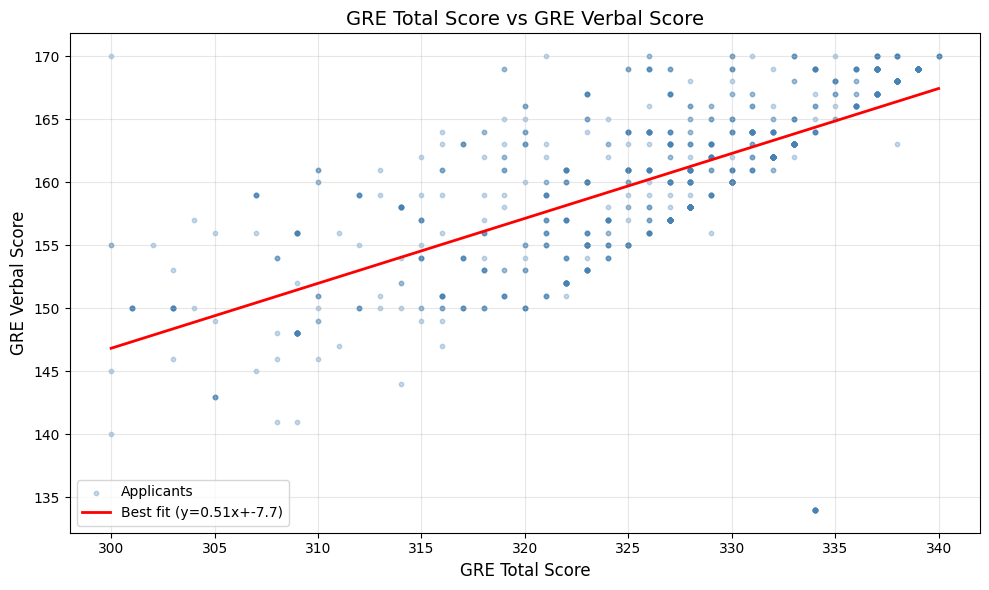

Saved: GRE-vs-GRE-V.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df[(df['GRE'] > 0) & (df['GRE V'] > 0)][['GRE', 'GRE V']].dropna()
ax.scatter(plot_df['GRE'], plot_df['GRE V'], alpha=0.3, s=10, color='steelblue', label='Applicants')

# NumPy best-fit line
m, b = np.polyfit(plot_df['GRE'], plot_df['GRE V'], 1)
x_line = np.linspace(plot_df['GRE'].min(), plot_df['GRE'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Best fit (y={m:.2f}x+{b:.1f})')

ax.set_title('GRE Total Score vs GRE Verbal Score', fontsize=14)
ax.set_xlabel('GRE Total Score', fontsize=12)
ax.set_ylabel('GRE Verbal Score', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GRE-vs-GRE-V.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: GRE-vs-GRE-V.png")

### 6.2 Scatter: GPA vs GRE

Visualize the relationship between GPA and total GRE score for applicants with valid values in both, with a NumPy best-fit line.

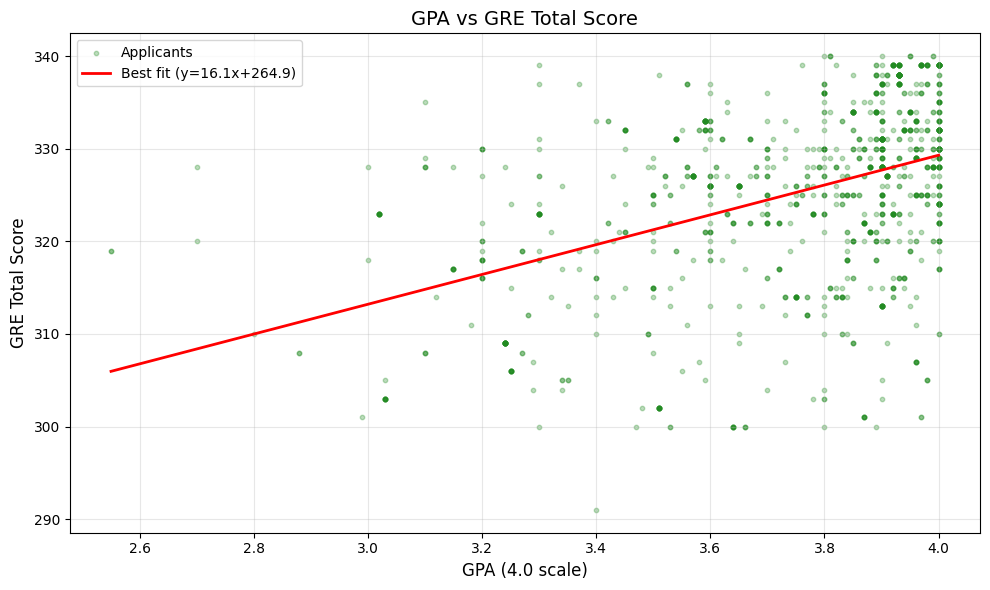

Saved: GPA-vs-GRE.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df[(df['GPA'] > 0) & (df['GPA'] <= 4.0) & (df['GRE'] > 0)][['GPA', 'GRE']].dropna()
ax.scatter(plot_df['GPA'], plot_df['GRE'], alpha=0.3, s=10, color='forestgreen', label='Applicants')

# NumPy best-fit line
m, b = np.polyfit(plot_df['GPA'], plot_df['GRE'], 1)
x_line = np.linspace(plot_df['GPA'].min(), plot_df['GPA'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Best fit (y={m:.1f}x+{b:.1f})')

ax.set_title('GPA vs GRE Total Score', fontsize=14)
ax.set_xlabel('GPA (4.0 scale)', fontsize=12)
ax.set_ylabel('GRE Total Score', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GPA-vs-GRE.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: GPA-vs-GRE.png")

### 6.3 Bar Chart: Degree vs US/International

Compare applicant counts by Degree type, broken down by US/International status.

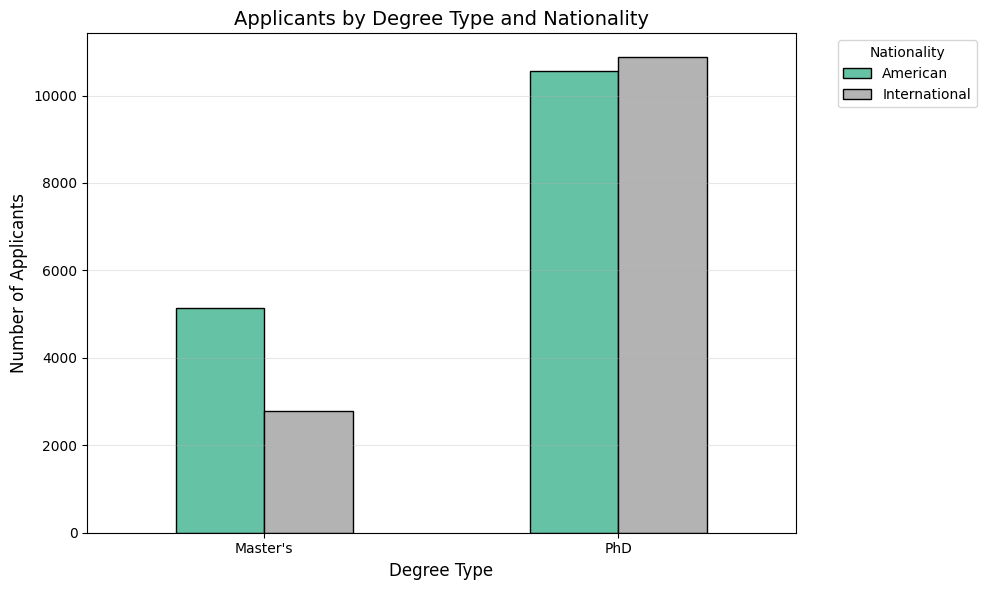

Saved: Degree-vs-International.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df.groupby(['Degree', 'US/International']).size().unstack(fill_value=0)
plot_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')

ax.set_title('Applicants by Degree Type and Nationality', fontsize=14)
ax.set_xlabel('Degree Type', fontsize=12)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('Degree-vs-International.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Degree-vs-International.png")

### 6.4 Histogram: Acceptances over Time

Show how accepted applicants' decision dates are distributed over time, binned into 3-day intervals.

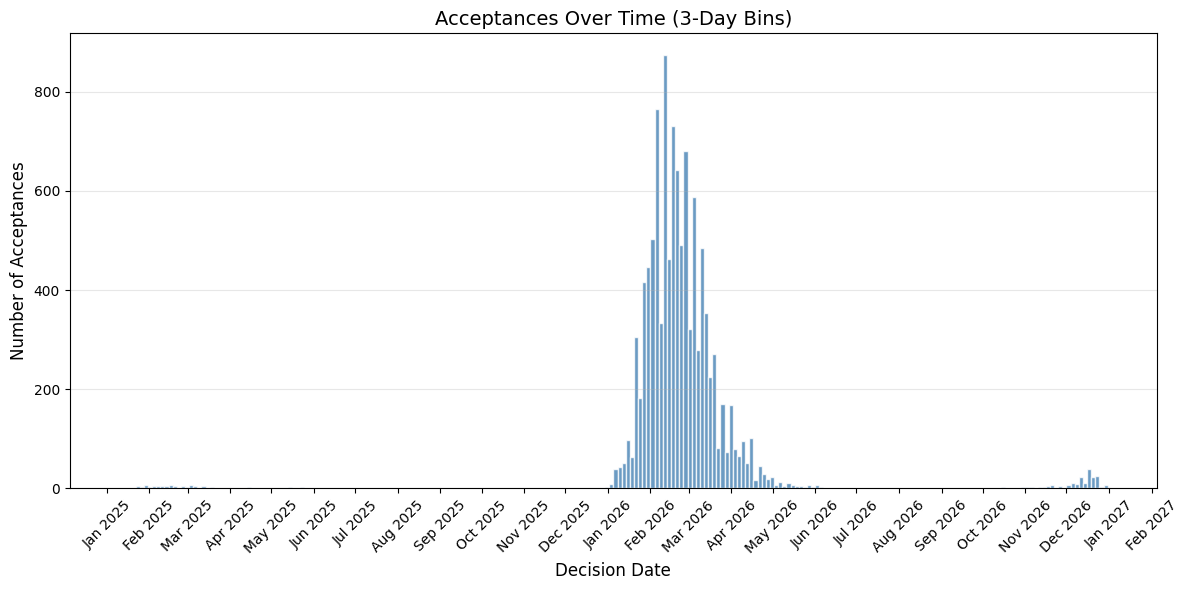

Saved: Acceptances-over-Time.png


In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

accepted = df[(df['outcome'] == 'Accepted') & df['decision_date'].notna()]['decision_date']

if len(accepted) > 0:
    min_date = accepted.min()
    max_date = accepted.max()
    bins = pd.date_range(start=min_date, end=max_date, freq='3D')
    ax.hist(accepted, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
else:
    ax.text(0.5, 0.5, 'No acceptance dates available', transform=ax.transAxes, ha='center')

ax.set_title('Acceptances Over Time (3-Day Bins)', fontsize=14)
ax.set_xlabel('Decision Date', fontsize=12)
ax.set_ylabel('Number of Acceptances', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('Acceptances-over-Time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Acceptances-over-Time.png")

### 6.5 Boxplot: GPA by Outcome

Compare the distribution of GPA across each outcome category.

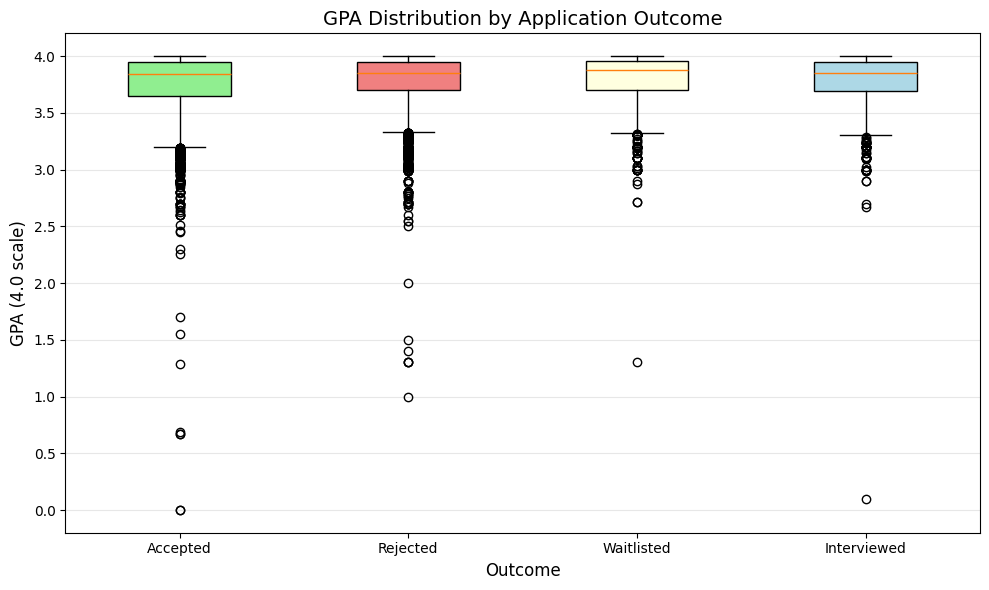

Saved: GPA-by-Outcome.png


In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

outcomes = ['Accepted', 'Rejected', 'Waitlisted', 'Interviewed']
gpa_by_outcome = [
    df[(df['outcome'] == o) & (df['has_valid_gpa'] == 1)]['GPA'].dropna().values
    for o in outcomes
]
gpa_by_outcome_filtered = [(o, g) for o, g in zip(outcomes, gpa_by_outcome) if len(g) > 0]

if gpa_by_outcome_filtered:
    labels, data = zip(*gpa_by_outcome_filtered)
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    colors = ['lightgreen', 'lightcoral', 'lightyellow', 'lightblue']
    for patch, color in zip(bp['boxes'], colors[:len(labels)]):
        patch.set_facecolor(color)

ax.set_title('GPA Distribution by Application Outcome', fontsize=14)
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('GPA (4.0 scale)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('GPA-by-Outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: GPA-by-Outcome.png")

### 6.6 Correlation Heatmap

Visualize pairwise correlation coefficients across all four numeric columns.

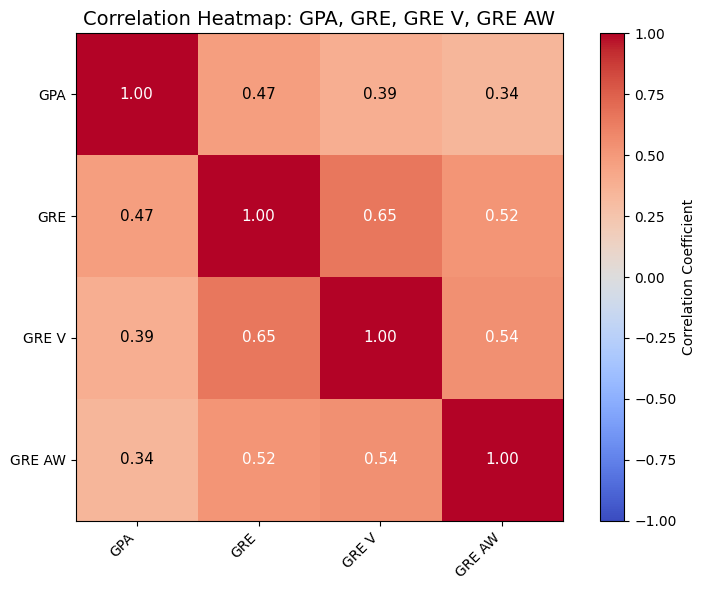

Saved: Numeric-Correlation-Heatmap.png


In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

numeric_cols = ['GPA', 'GRE', 'GRE V', 'GRE AW']
corr_df = df[numeric_cols].dropna()
corr_matrix = corr_df.corr()

im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation Coefficient')

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

# Add correlation values as text
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=11,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Correlation Heatmap: GPA, GRE, GRE V, GRE AW', fontsize=14)
plt.tight_layout()
plt.savefig('Numeric-Correlation-Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Numeric-Correlation-Heatmap.png")

## 7. Analytical Summary Values for analytics.pdf

Compute the code-generated values referenced in the written analytical summary (analytics.pdf), rather than typing any of these numbers in by hand.

In [36]:
# Q1: Average GRE score of accepted PhD applicants
accepted_phd_gre = df[
    (df['outcome'] == 'Accepted') &
    (df['Degree'] == 'PhD') &
    (df['GRE'] > 0)
]['GRE'].dropna()
print(f"Q1: Average GRE of accepted PhD applicants: {accepted_phd_gre.mean():.2f} (n={len(accepted_phd_gre)})")

# Q2: Average GPA of accepted Master's applicants
accepted_ms_gpa = df[
    (df['outcome'] == 'Accepted') &
    (df['Degree'] == "Master's") &
    (df['has_valid_gpa'] == 1)
]['GPA'].dropna()
print(f"Q2: Average GPA of accepted Master's applicants: {accepted_ms_gpa.mean():.4f} (n={len(accepted_ms_gpa)})")

print(f"\nCorrelation GRE vs GRE V: r={r_gre_grev:.4f}, p={p_gre_grev:.4e}")
print(f"Correlation GPA vs GRE (Spearman): r={r_gpa_gre:.4f}, p={p_gpa_gre:.4e}")
print(f"T-test Accepted vs Rejected GPA: t={t_stat:.4f}, p={p_val:.4e}")
print(f"Chi-square Degree vs Intl: chi2={chi2:.4f}, p={p_chi2:.4e}")

Q1: Average GRE of accepted PhD applicants: 327.30 (n=322)
Q2: Average GPA of accepted Master's applicants: 3.7166 (n=3929)

Correlation GRE vs GRE V: r=0.6727, p=4.9234e-140
Correlation GPA vs GRE (Spearman): r=0.4292, p=2.8559e-57
T-test Accepted vs Rejected GPA: t=-5.4654, p=4.6946e-08
Chi-square Degree vs Intl: chi2=563.6234, p=1.3690e-124


## 8. Export Cleaned Dataset and Upload to S3

Export the final cleaned DataFrame to JSON and upload it back to the S3 bucket, confirming the upload succeeded.

In [37]:
# Export cleaned DataFrame to JSON
cleaned_file = "cleaned_gradcafe.json"
df.to_json(cleaned_file, orient='records', date_format='iso', indent=2)
print(f"Exported cleaned dataset: {cleaned_file}")
print(f"Shape: {df.shape}")

Exported cleaned dataset: cleaned_gradcafe.json
Shape: (29831, 31)


In [38]:
# Upload cleaned JSON back to S3
s3.upload_file(cleaned_file, BUCKET, f"cleaned/{cleaned_file}")
print(f"Successfully uploaded {cleaned_file} to s3://{BUCKET}/cleaned/{cleaned_file}")

Successfully uploaded cleaned_gradcafe.json to s3://grad-cafe-ss/cleaned/cleaned_gradcafe.json


## ✅ Assignment Complete

**Remember to stop your SageMaker notebook instance after completing this assignment
to avoid unnecessary charges.**

Go to: AWS Console → SageMaker AI → Notebooks → Stop instance.